<a href="https://colab.research.google.com/github/i2mmmmm/train_project/blob/main/train_s2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets

In [2]:
from google.colab import drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
data_s30 = pd.read_csv('/content/drive/My Drive/철도/data_s30.csv')
data_s40 = pd.read_csv('/content/drive/My Drive/철도/data_s40.csv')
data_s50 = pd.read_csv('/content/drive/My Drive/철도/data_s50.csv')
data_s70 = pd.read_csv('/content/drive/My Drive/철도/data_s70.csv')
data_s100 = pd.read_csv('/content/drive/My Drive/철도/data_s100.csv')
lane_data_s = pd.read_csv('/content/drive/My Drive/철도/lane_data_s.csv')

In [17]:
new_column_name = {'Distance': 'Dis'}
lane_data_s = lane_data_s.rename(columns=new_column_name)

In [18]:
s30_trail = pd.concat([lane_data_s, data_s30],axis=1)
s30_trail = s30_trail.drop('Dis', axis=1)
s40_trail = pd.concat([lane_data_s, data_s40],axis=1)
s40_trail = s40_trail.drop('Dis', axis=1)
s50_trail = pd.concat([lane_data_s, data_s50],axis=1)
s50_trail = s50_trail.drop('Dis', axis=1)
s70_trail = pd.concat([lane_data_s, data_s70],axis=1)
s70_trail = s70_trail.drop('Dis', axis=1)
s100_trail = pd.concat([lane_data_s, data_s100],axis=1)
s100_trail = s100_trail.drop('Dis', axis=1)

In [ ]:
s30_trail

,Cross level,Curvature,Lateral,Vertical,Gauge,Distance,A_M1_C_B1_Y,A_M1_C_B1_Z,A_M1_B1_W1_Y_L,A_M1_B1_BC_Y_L,...,QL_M1_B1_W1,QR_M1_B1_W1,V_M1_B1_W2_L,V_M1_B1_W2_R,QL_M1_B1_W2,QR_M1_B1_W2,YL_M1_B1_W1,YR_M1_B1_W1,YL_M1_B1_W2,YR_M1_B1_W2
0,0.081,0.002,1.308,1.155,0.345,0.00,-1.273400e-09,-1.943500e-08,0.022194,0.022194,...,-0.305900,0.354800,0.000832,0.000847,0.000012,0.000012,0.001366,0.001558,0.001412,0.001406
1,0.251,0.002,1.282,1.157,0.151,0.25,1.485600e-05,3.403000e-06,0.161500,0.159800,...,-0.086214,0.088455,-0.010882,0.012985,-0.000163,0.000191,0.007337,-0.004638,0.001448,0.001525
2,0.421,0.002,1.256,1.159,-0.043,0.50,2.706500e-04,5.112900e-05,0.579500,0.569500,...,-0.085584,0.082844,-0.008447,0.010115,-0.000127,0.000149,0.011998,-0.009334,0.001715,0.001607
3,0.416,0.002,1.297,0.858,0.033,0.75,1.247900e-03,1.295900e-04,0.812000,0.789500,...,-0.249400,-0.187700,0.153500,-0.153900,0.002307,-0.002261,0.008566,-0.005116,0.002410,0.001200
4,0.412,0.002,1.337,0.558,0.110,1.00,3.080900e-03,-1.466900e-03,0.383100,0.349700,...,-0.289500,-0.268300,0.630800,-0.630400,0.009477,-0.009258,0.002605,0.001091,0.003430,0.000351
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,-0.639,-0.002,0.295,-0.503,-0.477,2998.75,9.026600e-02,8.505400e-02,-1.096000,-1.012000,...,0.213100,0.103000,-9.184000,-17.920000,-0.138000,-0.263100,0.000000,0.000000,0.000000,0.000000
11996,-0.827,-0.002,0.299,-0.785,-0.218,2999.00,1.043000e-01,9.336100e-02,-0.938800,0.048887,...,0.154200,0.051614,-8.026000,-22.840000,-0.120600,-0.335400,0.000000,0.000000,0.000000,0.000000
11997,-0.861,-0.001,0.116,-0.931,-0.048,2999.25,1.151000e-01,7.851500e-02,-0.405400,1.249000,...,0.098817,0.148900,-10.770000,-30.400000,-0.161800,-0.446400,0.000000,0.000000,0.000000,0.000000
11998,-0.894,0.000,-0.068,-1.077,0.122,2999.50,1.239000e-01,4.084100e-02,-0.312900,1.486000,...,0.001088,0.152100,-16.290000,-34.690000,-0.244800,-0.509500,0.000000,0.000000,0.000000,0.000000


In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, LeakyReLU, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping


In [19]:
# 데이터 전처리
def prepare_data(filename):
    data = filename
    X = data.drop(columns=["YL_M1_B1_W1", "YR_M1_B1_W1", "YL_M1_B1_W2", "YR_M1_B1_W2"])
    y = data[["YL_M1_B1_W1", "YR_M1_B1_W1", "YL_M1_B1_W2", "YR_M1_B1_W2"]]

    # 데이터 스케일링
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    return X, y

def reshape_data(X, y):
    X_list, y_list = [], []
    X_padded = np.vstack([np.zeros((N_TIMESTEPS, X.shape[1])), X])

    for i in range(len(X_padded) - N_TIMESTEPS):
        X_list.append(X_padded[i:i+N_TIMESTEPS])
        y_list.append(y.iloc[i])

    return np.array(X_list), np.array(y_list)

data_s_X, data_s_y = prepare_data(s30_trail)

# 모델 구축
N_TIMESTEPS = 10
N_FEATURES = 36

model = Sequential()

model.add(LSTM(100, input_shape=(N_TIMESTEPS, N_FEATURES), return_sequences=True))
model.add(BatchNormalization())
model.add(LeakyReLU())
model.add(Dropout(0.3))

model.add(LSTM(100))
model.add(BatchNormalization())
model.add(LeakyReLU())
model.add(Dropout(0.3))

model.add(Dense(4))

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

X_s, y_s = reshape_data(data_s_X, data_s_y)

# 트레이닝/테스트 데이터 나누기
X_train_s = X_s[:10001]
y_train_s = y_s[:10001]
X_test_s = X_s[10001:]
y_test_s = y_s[10001:]

# Early stopping
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10)

# 모델 학습
model.fit(X_train_s, y_train_s, epochs=100, batch_size=32, validation_data=(X_test_s, y_test_s), callbacks=[es])

# 예측
predictions_30 = model.predict(X_test_s)

# 예측 결과 출력
print("Predictions for data_s")
print(predictions_30[:5])


Epoch 1/100
313/313 [==============================] - 16s 32ms/step - loss: 0.2866 - mae: 0.3994 - val_loss: 0.0068 - val_mae: 0.0643
Epoch 2/100
313/313 [==============================] - 18s 59ms/step - loss: 0.0443 - mae: 0.1636 - val_loss: 0.0031 - val_mae: 0.0432
Epoch 3/100
313/313 [==============================] - 10s 32ms/step - loss: 0.0111 - mae: 0.0815 - val_loss: 0.0020 - val_mae: 0.0339
Epoch 4/100
313/313 [==============================] - 10s 33ms/step - loss: 0.0032 - mae: 0.0434 - val_loss: 0.0013 - val_mae: 0.0258
Epoch 5/100
313/313 [==============================] - 8s 27ms/step - loss: 0.0012 - mae: 0.0260 - val_loss: 0.0014 - val_mae: 0.0269
Epoch 6/100
313/313 [==============================] - 10s 32ms/step - loss: 7.4304e-04 - mae: 0.0187 - val_loss: 0.0012 - val_mae: 0.0245
Epoch 7/100
313/313 [==============================] - 10s 34ms/step - loss: 5.9232e-04 - mae: 0.0161 - val_loss: 0.0011 - val_mae: 0.0235
Epoch 8/100
313/313 [===========================

63/63 [==============================] - 2s 7ms/step


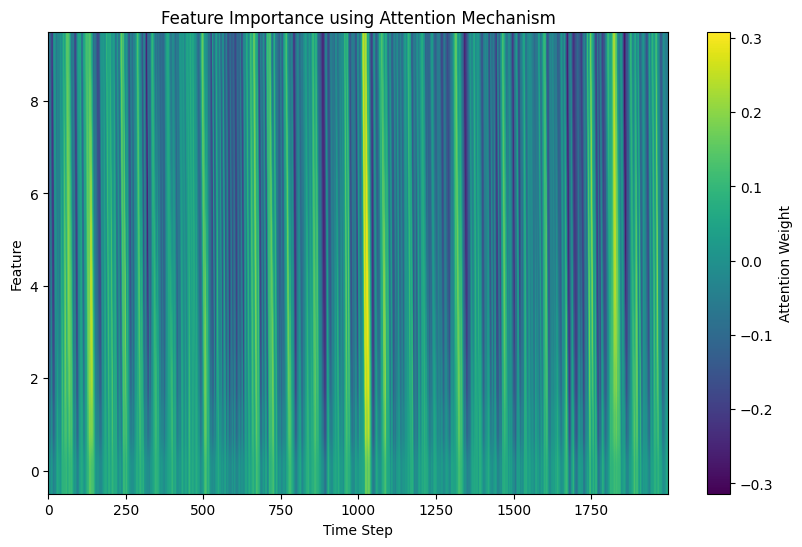

In [22]:
# Attention 메커니즘을 활용하여 특성 기여도 시각화
attention_model = Sequential()
attention_model.add(model.layers[0])  # 첫번째 LSTM 레이어 추가
attention_model.add(model.layers[1])  # BatchNormalization 레이어 추가

attention_output = attention_model.predict(X_test_s)  # predict 함수로 출력 활성화 값을 얻음
attention_weights = np.mean(attention_output, axis=2)

# 특성 기여도 시각화
plt.figure(figsize=(10, 6))
plt.imshow(attention_weights.T, cmap='viridis', origin='lower', aspect='auto')  # 수정된 부분
plt.colorbar(label='Attention Weight')
plt.xlabel('Time Step')
plt.ylabel('Feature')
plt.title('Feature Importance using Attention Mechanism')
plt.show()

In [20]:
predicted_30s = pd.DataFrame(predictions_30, columns=['YL_M1_B1_W1', 'YR_M1_B1_W1', 'YL_M1_B1_W2', 'YR_M1_B1_W2'])

# CSV 파일로 저장
predicted_30s.to_csv('/content/drive/My Drive/철도/predicted_30s2.csv', index=False)

In [28]:
# 데이터 전처리
def prepare_data(filename):
    data = filename
    X = data.drop(columns=["YL_M1_B1_W1", "YR_M1_B1_W1", "YL_M1_B1_W2", "YR_M1_B1_W2"])
    y = data[["YL_M1_B1_W1", "YR_M1_B1_W1", "YL_M1_B1_W2", "YR_M1_B1_W2"]]

    # 데이터 스케일링
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    return X, y

def reshape_data(X, y):
    X_list, y_list = [], []
    X_padded = np.vstack([np.zeros((N_TIMESTEPS, X.shape[1])), X])

    for i in range(len(X_padded) - N_TIMESTEPS):
        X_list.append(X_padded[i:i+N_TIMESTEPS])
        y_list.append(y.iloc[i])

    return np.array(X_list), np.array(y_list)

data_s_X, data_s_y = prepare_data(s40_trail)

# 모델 구축
N_TIMESTEPS = 10
N_FEATURES = 36

model = Sequential()

model.add(LSTM(100, input_shape=(N_TIMESTEPS, N_FEATURES), return_sequences=True))
model.add(BatchNormalization())
model.add(LeakyReLU())
model.add(Dropout(0.3))

model.add(LSTM(100))
model.add(BatchNormalization())
model.add(LeakyReLU())
model.add(Dropout(0.3))

model.add(Dense(4))

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

X_s, y_s = reshape_data(data_s_X, data_s_y)

# 트레이닝/테스트 데이터 나누기
X_train_s = X_s[:10001]
y_train_s = y_s[:10001]
X_test_s = X_s[10001:]
y_test_s = y_s[10001:]

# Early stopping
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10)

# 모델 학습
model.fit(X_train_s, y_train_s, epochs=100, batch_size=32, validation_data=(X_test_s, y_test_s), callbacks=[es])

# 예측
predictions_40 = model.predict(X_test_s)

# 예측 결과 출력
print("Predictions for data_s")
print(predictions_40[:5])

Epoch 1/100
313/313 [==============================] - 20s 36ms/step - loss: 0.2832 - mae: 0.3965 - val_loss: 0.0068 - val_mae: 0.0653
Epoch 2/100
313/313 [==============================] - 9s 30ms/step - loss: 0.0428 - mae: 0.1603 - val_loss: 0.0025 - val_mae: 0.0394
Epoch 3/100
313/313 [==============================] - 10s 31ms/step - loss: 0.0100 - mae: 0.0776 - val_loss: 9.2153e-04 - val_mae: 0.0236
Epoch 4/100
313/313 [==============================] - 10s 33ms/step - loss: 0.0027 - mae: 0.0405 - val_loss: 5.6736e-04 - val_mae: 0.0179
Epoch 5/100
313/313 [==============================] - 9s 28ms/step - loss: 8.9693e-04 - mae: 0.0229 - val_loss: 4.9081e-04 - val_mae: 0.0165
Epoch 6/100
313/313 [==============================] - 10s 31ms/step - loss: 4.5525e-04 - mae: 0.0160 - val_loss: 4.9764e-04 - val_mae: 0.0164
Epoch 7/100
313/313 [==============================] - 10s 32ms/step - loss: 3.5040e-04 - mae: 0.0138 - val_loss: 5.3382e-04 - val_mae: 0.0171
Epoch 8/100
313/313 [====

In [29]:
!pip install shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.9/547.9 kB 6.0 MB/s eta 0:00:00


In [36]:
# SHAP 값을 계산하고 시각화
explainer = shap.DeepExplainer(model, X_train_s)  # Deep Explainer 사용
shap_values = explainer.shap_values(X_test_s)
shap.summary_plot(shap_values, X_test_s)

keras is no longer supported, please use tf.keras instead.
Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
You have provided over 5k background samples! For better performance consider using smaller random sample.
`tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.


AttributeError: ignored

In [41]:
import shap

# SHAP를 사용하여 특성 기여도 계산 및 시각화
explainer = shap.Explainer(model, X_train_s)  # 모델과 학습 데이터를 지정해야 합니다.
shap_values = explainer(X_test_s)

# 특성 기여도 시각화
shap.summary_plot(shap_values, X_test_s)

TypeError: ignored

In [24]:
predicted_40s = pd.DataFrame(predictions_40, columns=['YL_M1_B1_W1', 'YR_M1_B1_W1', 'YL_M1_B1_W2', 'YR_M1_B1_W2'])

# CSV 파일로 저장
predicted_40s.to_csv('/content/drive/My Drive/철도/predicted_40s2.csv', index=False)

In [ ]:
# 데이터 전처리
def prepare_data(filename):
    data = filename
    X = data.drop(columns=["YL_M1_B1_W1", "YR_M1_B1_W1", "YL_M1_B1_W2", "YR_M1_B1_W2"])
    y = data[["YL_M1_B1_W1", "YR_M1_B1_W1", "YL_M1_B1_W2", "YR_M1_B1_W2"]]

    # 데이터 스케일링
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    return X, y

def reshape_data(X, y):
    X_list, y_list = [], []
    X_padded = np.vstack([np.zeros((N_TIMESTEPS, X.shape[1])), X])

    for i in range(len(X_padded) - N_TIMESTEPS):
        X_list.append(X_padded[i:i+N_TIMESTEPS])
        y_list.append(y.iloc[i])

    return np.array(X_list), np.array(y_list)

data_s_X, data_s_y = prepare_data(s50_trail)

# 모델 구축
N_TIMESTEPS = 10
N_FEATURES = 36

model = Sequential()

model.add(LSTM(100, input_shape=(N_TIMESTEPS, N_FEATURES), return_sequences=True))
model.add(BatchNormalization())
model.add(LeakyReLU())
model.add(Dropout(0.3))

model.add(LSTM(100))
model.add(BatchNormalization())
model.add(LeakyReLU())
model.add(Dropout(0.3))

model.add(Dense(4))

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

X_s, y_s = reshape_data(data_s_X, data_s_y)

# 트레이닝/테스트 데이터 나누기
X_train_s = X_s[:10001]
y_train_s = y_s[:10001]
X_test_s = X_s[10001:]
y_test_s = y_s[10001:]

# Early stopping
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10)

# 모델 학습
model.fit(X_train_s, y_train_s, epochs=100, batch_size=32, validation_data=(X_test_s, y_test_s), callbacks=[es])

# 예측
predictions_50 = model.predict(X_test_s)

# 예측 결과 출력
print("Predictions for data_s")
print(predictions_50[:5])

Epoch 1/100
313/313 [==============================] - 17s 36ms/step - loss: 0.3038 - mae: 0.4128 - val_loss: 0.0061 - val_mae: 0.0617
Epoch 2/100
313/313 [==============================] - 8s 27ms/step - loss: 0.0473 - mae: 0.1686 - val_loss: 0.0030 - val_mae: 0.0432
Epoch 3/100
313/313 [==============================] - 10s 32ms/step - loss: 0.0119 - mae: 0.0850 - val_loss: 0.0012 - val_mae: 0.0263
Epoch 4/100
313/313 [==============================] - 11s 34ms/step - loss: 0.0034 - mae: 0.0451 - val_loss: 6.8780e-04 - val_mae: 0.0200
Epoch 5/100
313/313 [==============================] - 8s 26ms/step - loss: 0.0012 - mae: 0.0262 - val_loss: 5.4864e-04 - val_mae: 0.0171
Epoch 6/100
313/313 [==============================] - 10s 33ms/step - loss: 5.3007e-04 - mae: 0.0177 - val_loss: 5.1216e-04 - val_mae: 0.0168
Epoch 7/100
313/313 [==============================] - 10s 33ms/step - loss: 3.7130e-04 - mae: 0.0145 - val_loss: 5.4482e-04 - val_mae: 0.0171
Epoch 8/100
313/313 [============

In [ ]:
predicted_50s = pd.DataFrame(predictions_50, columns=['YL_M1_B1_W1', 'YR_M1_B1_W1', 'YL_M1_B1_W2', 'YR_M1_B1_W2'])

# CSV 파일로 저장
predicted_50s.to_csv('/content/drive/My Drive/철도/predicted_50s.csv', index=False)

In [ ]:
# 데이터 전처리
def prepare_data(filename):
    data = filename
    X = data.drop(columns=["YL_M1_B1_W1", "YR_M1_B1_W1", "YL_M1_B1_W2", "YR_M1_B1_W2"])
    y = data[["YL_M1_B1_W1", "YR_M1_B1_W1", "YL_M1_B1_W2", "YR_M1_B1_W2"]]

    # 데이터 스케일링
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    return X, y

def reshape_data(X, y):
    X_list, y_list = [], []
    X_padded = np.vstack([np.zeros((N_TIMESTEPS, X.shape[1])), X])

    for i in range(len(X_padded) - N_TIMESTEPS):
        X_list.append(X_padded[i:i+N_TIMESTEPS])
        y_list.append(y.iloc[i])

    return np.array(X_list), np.array(y_list)

data_s_X, data_s_y = prepare_data(s70_trail)

# 모델 구축
N_TIMESTEPS = 10
N_FEATURES = 36

model = Sequential()

model.add(LSTM(100, input_shape=(N_TIMESTEPS, N_FEATURES), return_sequences=True))
model.add(BatchNormalization())
model.add(LeakyReLU())
model.add(Dropout(0.3))

model.add(LSTM(100))
model.add(BatchNormalization())
model.add(LeakyReLU())
model.add(Dropout(0.3))

model.add(Dense(4))

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

X_s, y_s = reshape_data(data_s_X, data_s_y)

# 트레이닝/테스트 데이터 나누기
X_train_s = X_s[:10001]
y_train_s = y_s[:10001]
X_test_s = X_s[10001:]
y_test_s = y_s[10001:]

# Early stopping
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10)

# 모델 학습
model.fit(X_train_s, y_train_s, epochs=100, batch_size=32, validation_data=(X_test_s, y_test_s), callbacks=[es])

# 예측
predictions_70 = model.predict(X_test_s)

# 예측 결과 출력
print("Predictions for data_s")
print(predictions_70[:5])

Epoch 1/100
313/313 [==============================] - 16s 36ms/step - loss: 0.2666 - mae: 0.3864 - val_loss: 0.0055 - val_mae: 0.0581
Epoch 2/100
313/313 [==============================] - 8s 26ms/step - loss: 0.0395 - mae: 0.1538 - val_loss: 0.0026 - val_mae: 0.0399
Epoch 3/100
313/313 [==============================] - 10s 32ms/step - loss: 0.0093 - mae: 0.0750 - val_loss: 9.0114e-04 - val_mae: 0.0235
Epoch 4/100
313/313 [==============================] - 10s 32ms/step - loss: 0.0025 - mae: 0.0388 - val_loss: 5.6442e-04 - val_mae: 0.0180
Epoch 5/100
313/313 [==============================] - 8s 26ms/step - loss: 8.2662e-04 - mae: 0.0221 - val_loss: 4.1625e-04 - val_mae: 0.0154
Epoch 6/100
313/313 [==============================] - 10s 32ms/step - loss: 4.3501e-04 - mae: 0.0158 - val_loss: 4.5174e-04 - val_mae: 0.0155
Epoch 7/100
313/313 [==============================] - 9s 28ms/step - loss: 3.3798e-04 - mae: 0.0137 - val_loss: 4.6236e-04 - val_mae: 0.0161
Epoch 8/100
313/313 [=====

In [ ]:
predicted_70s = pd.DataFrame(predictions_70, columns=['YL_M1_B1_W1', 'YR_M1_B1_W1', 'YL_M1_B1_W2', 'YR_M1_B1_W2'])

# CSV 파일로 저장
predicted_70s.to_csv('/content/drive/My Drive/철도/predicted_70s.csv', index=False)

In [ ]:
# 데이터 전처리
def prepare_data(filename):
    data = filename
    X = data.drop(columns=["YL_M1_B1_W1", "YR_M1_B1_W1", "YL_M1_B1_W2", "YR_M1_B1_W2"])
    y = data[["YL_M1_B1_W1", "YR_M1_B1_W1", "YL_M1_B1_W2", "YR_M1_B1_W2"]]

    # 데이터 스케일링
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    return X, y

def reshape_data(X, y):
    X_list, y_list = [], []
    X_padded = np.vstack([np.zeros((N_TIMESTEPS, X.shape[1])), X])

    for i in range(len(X_padded) - N_TIMESTEPS):
        X_list.append(X_padded[i:i+N_TIMESTEPS])
        y_list.append(y.iloc[i])

    return np.array(X_list), np.array(y_list)

data_s_X, data_s_y = prepare_data(s100_trail)

# 모델 구축
N_TIMESTEPS = 10
N_FEATURES = 36

model = Sequential()

model.add(LSTM(100, input_shape=(N_TIMESTEPS, N_FEATURES), return_sequences=True))
model.add(BatchNormalization())
model.add(LeakyReLU())
model.add(Dropout(0.3))

model.add(LSTM(100))
model.add(BatchNormalization())
model.add(LeakyReLU())
model.add(Dropout(0.3))

model.add(Dense(4))

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

X_s, y_s = reshape_data(data_s_X, data_s_y)

# 트레이닝/테스트 데이터 나누기
X_train_s = X_s[:10001]
y_train_s = y_s[:10001]
X_test_s = X_s[10001:]
y_test_s = y_s[10001:]

# Early stopping
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10)

# 모델 학습
model.fit(X_train_s, y_train_s, epochs=100, batch_size=32, validation_data=(X_test_s, y_test_s), callbacks=[es])

# 예측
predictions_100 = model.predict(X_test_s)

# 예측 결과 출력
print("Predictions for data_s")
print(predictions_100[:5])

Epoch 1/100
313/313 [==============================] - 17s 36ms/step - loss: 0.2601 - mae: 0.3808 - val_loss: 0.0073 - val_mae: 0.0690
Epoch 2/100
313/313 [==============================] - 10s 33ms/step - loss: 0.0367 - mae: 0.1485 - val_loss: 0.0028 - val_mae: 0.0415
Epoch 3/100
313/313 [==============================] - 9s 27ms/step - loss: 0.0086 - mae: 0.0719 - val_loss: 0.0010 - val_mae: 0.0253
Epoch 4/100
313/313 [==============================] - 10s 33ms/step - loss: 0.0025 - mae: 0.0383 - val_loss: 5.3682e-04 - val_mae: 0.0174
Epoch 5/100
313/313 [==============================] - 10s 33ms/step - loss: 8.9555e-04 - mae: 0.0228 - val_loss: 4.6123e-04 - val_mae: 0.0158
Epoch 6/100
313/313 [==============================] - 9s 28ms/step - loss: 4.5095e-04 - mae: 0.0160 - val_loss: 5.4231e-04 - val_mae: 0.0166
Epoch 7/100
313/313 [==============================] - 10s 33ms/step - loss: 3.2917e-04 - mae: 0.0135 - val_loss: 4.8368e-04 - val_mae: 0.0158
Epoch 8/100
313/313 [========

In [ ]:
predicted_100s = pd.DataFrame(predictions_100, columns=['YL_M1_B1_W1', 'YR_M1_B1_W1', 'YL_M1_B1_W2', 'YR_M1_B1_W2'])

# CSV 파일로 저장
predicted_100s.to_csv('/content/drive/My Drive/철도/predicted_100s.csv', index=False)

In [4]:
answer_sample = pd.read_csv('/content/drive/My Drive/철도/answer_sample.csv')
c30 = pd.read_csv('/content/drive/My Drive/철도/predicted_30.csv')
c40 = pd.read_csv('/content/drive/My Drive/철도/predicted_40.csv')
c50 = pd.read_csv('/content/drive/My Drive/철도/predicted_50.csv')
c70 = pd.read_csv('/content/drive/My Drive/철도/predicted_70.csv')
c100 = pd.read_csv('/content/drive/My Drive/철도/predicted_100.csv')
s30 = pd.read_csv('/content/drive/My Drive/철도/predicted_30s.csv')
s40 = pd.read_csv('/content/drive/My Drive/철도/predicted_40s.csv')
s50 = pd.read_csv('/content/drive/My Drive/철도/predicted_50s.csv')
s70 = pd.read_csv('/content/drive/My Drive/철도/predicted_70s.csv')
s100 = pd.read_csv('/content/drive/My Drive/철도/predicted_100s.csv')


In [5]:
answer_sample

,Distance,YL_M1_B1_W1_s30,YR_M1_B1_W1_s30,YL_M1_B1_W2_s30,YR_M1_B1_W2_s30,YL_M1_B1_W1_s40,YR_M1_B1_W1_s40,YL_M1_B1_W2_s40,YR_M1_B1_W2_s40,YL_M1_B1_W1_s50,...,YL_M1_B1_W2_c50,YR_M1_B1_W2_c50,YL_M1_B1_W1_c70,YR_M1_B1_W1_c70,YL_M1_B1_W2_c70,YR_M1_B1_W2_c70,YL_M1_B1_W1_c100,YR_M1_B1_W1_c100,YL_M1_B1_W2_c100,YR_M1_B1_W2_c100
0,2500.25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2500.50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2500.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2501.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2501.25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1994,2998.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1995,2999.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1996,2999.25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1997,2999.50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
c30.columns = ['YL_M1_B1_W1_c30', 'YR_M1_B1_W1_c30', 'YL_M1_B1_W2_c30', 'YR_M1_B1_W2_c30']
c40.columns = ['YL_M1_B1_W1_c40', 'YR_M1_B1_W1_c40', 'YL_M1_B1_W2_c40', 'YR_M1_B1_W2_c40']
c50.columns = ['YL_M1_B1_W1_c50', 'YR_M1_B1_W1_c50', 'YL_M1_B1_W2_c50', 'YR_M1_B1_W2_c50']
c70.columns = ['YL_M1_B1_W1_c70', 'YR_M1_B1_W1_c70', 'YL_M1_B1_W2_c70', 'YR_M1_B1_W2_c70']
c100.columns = ['YL_M1_B1_W1_c100', 'YR_M1_B1_W1_c100', 'YL_M1_B1_W2_c100', 'YR_M1_B1_W2_c100']

s30.columns = ['YL_M1_B1_W1_s30', 'YR_M1_B1_W1_s30', 'YL_M1_B1_W2_s30', 'YR_M1_B1_W2_s30']
s40.columns = ['YL_M1_B1_W1_s40', 'YR_M1_B1_W1_s40', 'YL_M1_B1_W2_s40', 'YR_M1_B1_W2_s40']
s50.columns = ['YL_M1_B1_W1_s50', 'YR_M1_B1_W1_s50', 'YL_M1_B1_W2_s50', 'YR_M1_B1_W2_s50']
s70.columns = ['YL_M1_B1_W1_s70', 'YR_M1_B1_W1_s70', 'YL_M1_B1_W2_s70', 'YR_M1_B1_W2_s70']
s100.columns = ['YL_M1_B1_W1_s100', 'YR_M1_B1_W1_s100', 'YL_M1_B1_W2_s100', 'YR_M1_B1_W2_s100']

# 데이터

In [12]:
answer = pd.concat([answer_sample.Distance, s30,s40,s50,s70,s100,c30,c40,c50,c70,c100], axis=1)

In [13]:
answer

,Distance,YL_M1_B1_W1_s30,YR_M1_B1_W1_s30,YL_M1_B1_W2_s30,YR_M1_B1_W2_s30,YL_M1_B1_W1_s40,YR_M1_B1_W1_s40,YL_M1_B1_W2_s40,YR_M1_B1_W2_s40,YL_M1_B1_W1_s50,...,YL_M1_B1_W2_c50,YR_M1_B1_W2_c50,YL_M1_B1_W1_c70,YR_M1_B1_W1_c70,YL_M1_B1_W2_c70,YR_M1_B1_W2_c70,YL_M1_B1_W1_c100,YR_M1_B1_W1_c100,YL_M1_B1_W2_c100,YR_M1_B1_W2_c100
0,2500.25,0.033225,-0.006394,0.072091,-0.055342,-0.002652,0.009794,-0.009356,0.021929,-0.000736,...,-0.000559,0.005102,0.000861,0.004264,0.005170,0.004333,0.007408,0.002034,0.001685,0.008436
1,2500.50,0.032827,-0.003683,0.077266,-0.060096,-0.004485,0.012737,-0.003076,0.015533,-0.001399,...,0.005168,-0.001199,-0.000685,0.005504,0.010747,-0.000533,0.008118,0.001402,0.008461,0.001499
2,2500.75,0.030738,0.000333,0.082281,-0.064885,-0.006373,0.015662,0.004582,0.007416,-0.002517,...,0.010955,-0.007777,-0.003534,0.008503,0.018361,-0.007557,0.007911,0.001856,0.018185,-0.007890
3,2501.00,0.027266,0.004080,0.083746,-0.066681,-0.007645,0.017847,0.011764,0.000227,-0.006139,...,0.017463,-0.015074,-0.006240,0.011964,0.027127,-0.016236,0.006387,0.004086,0.029013,-0.018533
4,2501.25,0.023790,0.007207,0.082448,-0.065674,-0.007598,0.017811,0.018484,-0.007734,-0.009742,...,0.023357,-0.021619,-0.007969,0.014951,0.034875,-0.024354,0.004696,0.006458,0.036151,-0.025281
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1994,2998.75,0.012934,-0.002573,0.057187,-0.048345,0.007613,0.003490,0.057529,-0.047296,0.012600,...,0.032286,-0.027091,0.004271,0.004374,0.037239,-0.029086,0.010147,-0.000588,0.040809,-0.034061
1995,2999.00,0.011970,0.002782,0.048449,-0.038590,0.004259,0.006462,0.049680,-0.040274,0.011882,...,0.024537,-0.019481,0.001162,0.007585,0.030567,-0.023016,0.009424,0.001116,0.030834,-0.023407
1996,2999.25,0.012521,0.002413,0.041805,-0.031543,0.001002,0.008607,0.043012,-0.034731,0.012831,...,0.018813,-0.013614,0.001790,0.006642,0.027543,-0.019731,0.010065,0.000792,0.020454,-0.013178
1997,2999.50,0.014616,-0.003886,0.032946,-0.022707,0.000638,0.007949,0.033072,-0.025391,0.013606,...,0.014599,-0.008545,0.005121,0.002813,0.024284,-0.016083,0.011938,-0.001309,0.009082,-0.002824


In [14]:
answer.to_csv('/content/drive/My Drive/철도/answer.csv', index=False)